# Coherent Im begging please

First of all lets train a DT on all of exfor to predict a n,2n spectrum for a couple isotopes 



could train XG on all exfor a,z,n 

local isotopes endf and features available 

residuals




then simmilar autogluon see if theres any real change

can add Gaussian process regression to xg probably? defo for exfor and depending on feature eng method and in some way residuals



    

if we want the conclsuion to be ML can do what humans can do but withlut the physic sknowldge find difference between theory and ML with no physics on data rich isototpes and maybe actual evaluation. explain where it can't do anything with naive implemntation 
\




first lets look at the datsets once we load them, be that the exfor endf tendl xs and e values make sure units are same



plot them all out and hope they overlap do it with nucml then my own method 



then train a ML on 

In [2]:
import nucml.datasets as nuc_data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df_master_raw = nuc_data.load_exfor()

# 2. Filter: (n,2n) and Mass Range 20-200
df_2n = df_master_raw[
    (df_master_raw['MT'].astype(float) == 16.0) & 
    (df_master_raw['A'] >= 20) & 
    (df_master_raw['A'] <= 200)
].copy()

# 3. Clean Names & Physics Parameters
df_2n['Isotope_Norm'] = df_2n['Isotope'].str.lower().str.replace('-', '').str.strip()
df_2n['N'] = df_2n['A'] - df_2n['Z']
df_2n['Energy_Log'] = np.log10(df_2n['Energy'] + 1e-5)

# 4. Define Test Targets (Quarantine these from training)
target_isos = ['58ni', '197au', '93nb']

# 5. The Residual Auditor (Calculating the 'Physics Baseline')
final_rows = []
for iso in df_2n['Isotope'].unique():
    iso_batch = df_2n[df_2n['Isotope'] == iso].copy()
    try:
        tendl = nuc_data.load_evaluation(iso.lower(), 16, library='tendl.2019')
        if tendl is None or tendl.empty: continue
        
        # Linear eV Exp -> Log10 eV Theory interpolation
        theory_xs = np.interp(np.log10(iso_batch['Energy']), tendl['Energy'], tendl['Data'])
        
        # Only keep points where theory > 0
        valid = theory_xs > 1e-9
        if np.any(valid):
            # Target for Residual Method
            iso_batch.loc[iso_batch.index[valid], 'residual'] = np.log10(iso_batch['Data'][valid] + 1e-10) - np.log10(theory_xs[valid] + 1e-10)
            iso_batch.loc[iso_batch.index[valid], 'theory_val'] = theory_xs[valid]
            final_rows.append(iso_batch[valid])
    except: continue

df_final = pd.concat(final_rows, ignore_index=True)
features = ['A', 'Z', 'N', 'Energy_Log']

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Na023/tendl.2019/tables/xs/n-Na023-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-package

In [3]:
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Split
train_df = df_final[~df_final['Isotope_Norm'].isin(target_isos)].copy()
test_df = df_final[df_final['Isotope_Norm'].isin(target_isos)].copy()

# --- MODEL 1: DIRECT XG (Predicting Cross Section) ---
model_direct = XGBRegressor(n_estimators=500, learning_rate=0.05)
model_direct.fit(train_df[features], np.log10(train_df['Data'] + 1e-10))

# --- MODEL 2: RESIDUAL XG (Predicting Library Error) ---
model_res = XGBRegressor(n_estimators=500, learning_rate=0.05)
model_res.fit(train_df[features], train_df['residual'])

# --- MODEL 3: GPR REFINEMENT ---
# We use GPR on the residuals of our training set to learn local correlations
kernel = C(1.0) * RBF(1.0)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1)
# Training on a sample to save memory
gpr.fit(train_df[features].sample(1000), train_df['residual'].sample(1000))

,kernel,1**2 * RBF(length_scale=1)
,alpha,0.1
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=1)
,kernel__k1__constant_value,1.0


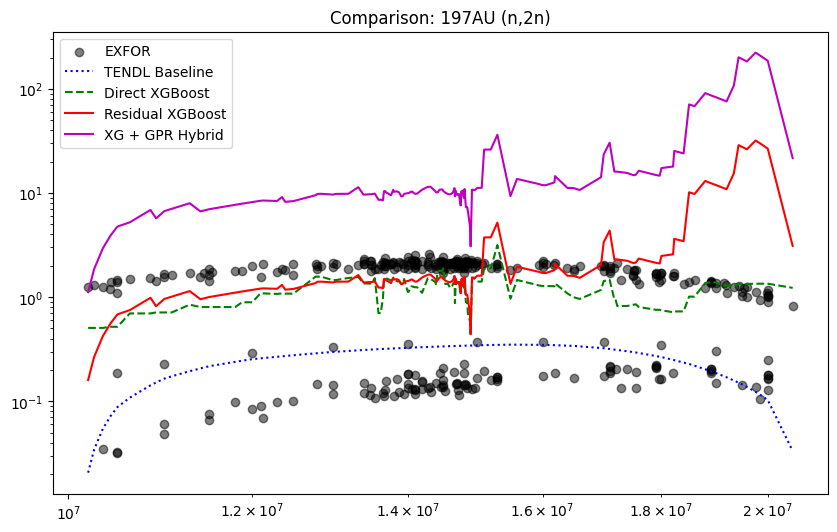

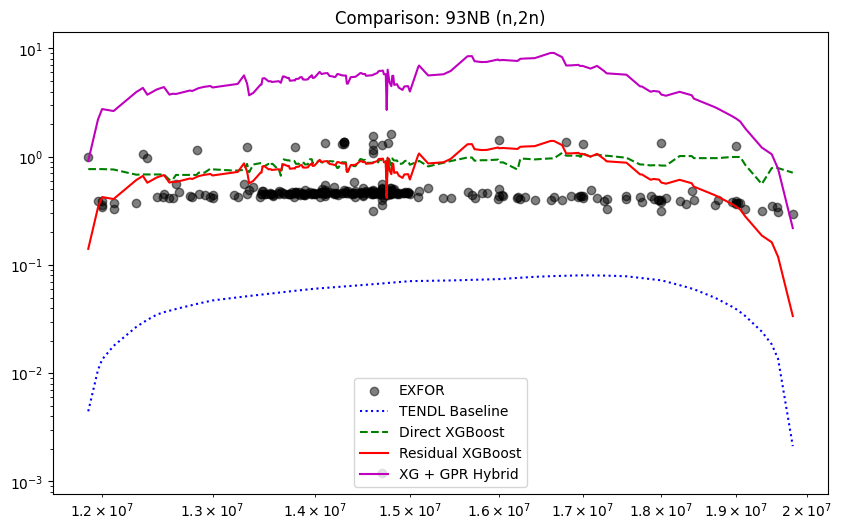

In [5]:
import matplotlib.pyplot as plt

for iso in target_isos:
    iso_data = test_df[test_df['Isotope_Norm'] == iso].sort_values('Energy').copy()
    if iso_data.empty: continue
    
    # Direct XG Path
    direct_pred = 10**model_direct.predict(iso_data[features])
    
    # Residual XG Path
    xg_res = model_res.predict(iso_data[features])
    res_pred = iso_data['theory_val'] * (10**xg_res)
    
    # XG + GPR Hybrid Path
    gpr_res, gpr_std = gpr.predict(iso_data[features], return_std=True)
    hybrid_pred = iso_data['theory_val'] * (10**(xg_res + gpr_res))

    plt.figure(figsize=(10, 6))
    plt.scatter(iso_data['Energy'], iso_data['Data'], color='black', alpha=0.5, label='EXFOR')
    plt.plot(iso_data['Energy'], iso_data['theory_val'], 'b:', label='TENDL Baseline')
    plt.plot(iso_data['Energy'], direct_pred, 'g--', label='Direct XGBoost')
    plt.plot(iso_data['Energy'], res_pred, 'r-', label='Residual XGBoost')
    plt.plot(iso_data['Energy'], hybrid_pred, 'm-', label='XG + GPR Hybrid')
    
    plt.xscale('log'); plt.yscale('log')
    plt.title(f"Comparison: {iso.upper()} (n,2n)")
    plt.legend()
    plt.show()

In [4]:
#find where the evaluation files are stored
import os  
import glob 
eval_dir = os.path.join(os.path.expanduser('~'), '.nucml', 'evaluations')
print(f"Evaluation files are stored in: {eval_dir}")

#find the name of library to call the endf evaluation files
library_name = 'endf-viii.0'
print(f"To load ENDF evaluations, use library='{library_name}' in nuc_data.load_evaluation()")
#find files to check if this path is correct

endf_files = glob.glob(os.path.join(eval_dir, library_name, '*.h5'))
print(f"Found ENDF evaluation files: {endf_files}")

#glob for endf anywhere
endf_files = glob.glob(os.path.join(eval_dir, 'endf-viii.0', '*.h5'))
print(f"Glob found ENDF evaluation files: {endf_files}")
#path is /Users/glsw/main/NucMLClone2/Evaluated_Data



Evaluation files are stored in: /Users/glsw/.nucml/evaluations
To load ENDF evaluations, use library='endf-viii.0' in nuc_data.load_evaluation()
Found ENDF evaluation files: []
Glob found ENDF evaluation files: []


In [6]:
df_eval_2n=pd.DataFrame()

#making evaluated datarame, want to train off a lot of isotopes need a way to load all the data, not isotope by isotope
for isotope in df_2n['Isotope'].unique():
    Isotope_name = isotope.lower().replace('-', '').strip()
    #if endf file exists for this isotope, load it and append to the evaluation dataframe
    if Isotope_name in endf_files:
        df_eval_2n = pd.concat([df_eval_2n, nuc_data.load_evaluation(mode='neutrons',MT=16, isotope= Isotope_name,library='endfb8.0',mev_to_ev=True,mb_to_b=True)], ignore_index=True)

test_isotopes= ['58ni', '197au', '93nb']
train_2n_df= df_final[~df_final['Isotope_Norm'].isin(test_isotopes)].copy()

#now we add A,Z,N,binding energy, and energy log to the evaluation dataframe
AME_info_df= nuc_data.load_ame(file="mass16")

#look at AME so we know what columns to merge on
print(AME_info_df.columns)

INFO:root:AME: Reading and loading the Atomic Mass Evaluation file from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_mass16.csv


Index(['N', 'Z', 'A', 'EL', 'O', 'Mass_Excess', 'dMass_Excess',
       'Binding_Energy', 'dBinding_Energy', 'B_Decay_Energy',
       'dB_Decay_Energy', 'Atomic_Mass_Micro', 'dAtomic_Mass_Micro',
       'Element_w_A'],
      dtype='object')


In [37]:
# # we now know the headers are Index(['N', 'Z', 'A', 'EL', 'O', 'Mass_Excess', 'dMass_Excess',
#        'Binding_Energy', 'dBinding_Energy', 'B_Decay_Energy',
#        'dB_Decay_Energy', 'Atomic_Mass_Micro', 'dAtomic_Mass_Micro',
#        'Element_w_A'],
#       dtype='object')

#add isotope column to AME for merging
AME_info_df['Isotope'] = AME_info_df['Element_w_A'].str.lower().str.replace('-', '').str.strip()
# now we need binding energy which is called dBinding_Energy in AME, we will rename it to BE for simplicity
AME_info_df.rename(columns={'dBinding_Energy': 'BE'}, inplace=True)

training_df= pd.merge(train_2n_df,AME_info_df[['Isotope','A','Z','N','BE']], left_on='Isotope_Norm', right_on='Isotope', how='left')
training_df['Energy_Log'] = np.log10(training_df['Energy'] )

In [38]:
#lets look at our full training df to check it has what we want 
print(training_df.head())

  Projectile Target_Metastable_State  MT Product_Metastable_State  \
0    neutron            All_or_Total  16             All_or_Total   
1    neutron            All_or_Total  16             All_or_Total   
2    neutron            All_or_Total  16             All_or_Total   
3    neutron            All_or_Total  16             All_or_Total   
4    neutron            All_or_Total  16             All_or_Total   

  EXFOR_Status Center_of_Mass_Flag      Energy        dEnergy   Data  dData  \
0        Other                 Lab  15300000.0  240378.480745  1.000  0.018   
1        Other                 Lab  15400000.0  241949.581926  1.006  0.018   
2        Other                 Lab  15500000.0  243520.683107  1.012  0.018   
3        Other                 Lab  15600000.0  245091.784289  1.017  0.019   
4        Other                 Lab  15700000.0  246662.885470  1.021  0.020   

   ...    NZ_tag  Isotope_Norm Energy_Log  residual theory_val  Isotope_y A_y  \
0  ...  even_odd          65c

In [53]:
#now we need to train our models on this training dataframe, we will use the same features as before but now we have more isotopes to train on and we also have binding energy as a feature which may help the model learn better
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Ensure required columns exist after the merge (handle A/Z/N/BE with possible suffixes)
needed = ['A', 'Z', 'N', 'BE', 'Energy_Log']
for c in ['A','Z','N','BE']:
    if c not in training_df.columns:
        for suf in ('', '_x', '_y'):
            cand = c + suf
            if cand in training_df.columns:
                training_df[c] = training_df[cand]
                break

# If Energy_Log missing, compute it
if 'Energy_Log' not in training_df.columns and 'Energy' in training_df.columns:
    training_df['Energy_Log'] = np.log10(training_df['Energy'] + 1e-10)

# Drop rows missing any needed feature or target
missing = training_df[needed + ['Data']].isnull().any(axis=1)
if missing.any():
    print(f"Dropping {missing.sum()} rows with missing features/target")
training_df = training_df.loc[~missing].copy()

# Now set features and fit
features = ['A', 'Z', 'N', 'Energy_Log']
print("Training columns:", training_df.columns.tolist())
print("Training rows:", len(training_df))

Training columns: ['Projectile', 'Target_Metastable_State', 'MT', 'Product_Metastable_State', 'EXFOR_Status', 'Center_of_Mass_Flag', 'Energy', 'dEnergy', 'Data', 'dData', 'ELV/HL', 'dELV/HL', 'I78', 'Short_Reference', 'EXFOR_Accession_Number', 'EXFOR_SubAccession_Number', 'EXFOR_Pointer', 'Z_x', 'Reaction_Notation', 'Title', 'Year', 'Author', 'Institute', 'Date', 'Reference', 'Dataset_Number', 'EXFOR_Entry', 'Reference_Code', 'Projectile_Z', 'Projectile_A', 'Projectile_N', 'Isotope_x', 'Element', 'N_x', 'A_x', 'Element_Flag', 'Nucleus_Radius', 'Neutron_Nucleus_Radius_Ratio', 'O', 'Mass_Excess', 'dMass_Excess', 'Binding_Energy', 'dBinding_Energy', 'B_Decay_Energy', 'dB_Decay_Energy', 'Atomic_Mass_Micro', 'dAtomic_Mass_Micro', 'S(2n)', 'dS(2n)', 'S(2p)', 'dS(2p)', 'Q(a)', 'dQ(a)', 'Q(2B-)', 'dQ(2B-)', 'Q(ep)', 'dQ(ep)', 'Q(B-n)', 'dQ(B-n)', 'S(n)', 'dS(n)', 'S(p)', 'dS(p)', 'Q(4B-)', 'dQ(4B-)', 'Q(d,a)', 'dQ(d,a)', 'Q(p,a)', 'dQ(p,a)', 'Q(n,a)', 'dQ(n,a)', 'Q(g,p)', 'Q(g,n)', 'Q(g,pn)', 

In [46]:
#make our xgboost models using the data frame we made and giving all the coulmuns as features except for the data and the theory value which we will use for the residual model
features = ['A', 'Z', 'N', 'BE', 'Energy_Log']

# --- MODEL 1: DIRECT XG (Predicting Cross Section) ---
model_direct = XGBRegressor(n_estimators=500, learning_rate=0.05)
model_direct.fit(training_df[features], np.log10(training_df['Data'] + 1e-10)) 

#use the training on the test isotopes to see how well the model does, we will compare the direct xgboost prediction to the residual xgboost prediction and the hybrid xgboost + gpr prediction
test_isotopes= [ '197au', '93nb']
test_df = df_final[df_final['Isotope_Norm'].isin(test_isotopes)].copy()
test_df = pd.merge(test_df, AME_info_df[['Isotope','A','Z','N','BE']], left_on='Isotope_Norm', right_on='Isotope', how='left')
test_df['Energy_Log'] = np.log10(test_df['Energy'] )    

#predict for test isotopes using the direct xgboost model





In [48]:
# Visualization for most recently trained model (cell 46)
import matplotlib.pyplot as plt
import numpy as np

features = ['A', 'Z', 'N', 'BE', 'Energy_Log']

for iso in test_isotopes:
    iso_df = test_df[test_df['Isotope_Norm'] == iso].sort_values('Energy').copy()
    if iso_df.empty:
        print(f"No data for {iso}")
        continue
    
    # Predictions
    direct_log = model_direct.predict(iso_df[features])
    direct_pred = 10 ** direct_log
    
    xg_res = model_res.predict(iso_df[features])
    res_pred = iso_df['theory_val'].values * (10 ** xg_res)
    
    gpr_res, _ = gpr.predict(iso_df[features], return_std=True)
    hybrid_pred = iso_df['theory_val'].values * (10 ** (xg_res + gpr_res))
    
    true_vals = iso_df['Data'].values
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(iso_df['Energy'], true_vals, color='k', s=20, alpha=0.6, label='EXFOR')
    plt.plot(iso_df['Energy'], iso_df['theory_val'].values, 'b:', linewidth=2, label='Theory')
    plt.plot(iso_df['Energy'], direct_pred, 'g--', linewidth=2, label='Direct XG')
    plt.plot(iso_df['Energy'], res_pred, 'r-', linewidth=2, label='Residual XG')
    plt.plot(iso_df['Energy'], hybrid_pred, 'm-', linewidth=2, label='Hybrid (XG+GPR)')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)')
    plt.ylabel('Cross section (barns)')
    plt.title(f'{iso.upper()} (n,2n) - Model Predictions')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

KeyError: "['A', 'Z', 'N'] not in index"

In [51]:
# Visualization for most recently trained model (cell 46)
import matplotlib.pyplot as plt
import numpy as np

features = ['A', 'Z', 'N', 'Energy_Log']
#'BE'
# Normalize test_df column names (handle suffixes from merge)
for c in ['A', 'Z', 'N', 'BE']:
    if c not in test_df.columns:
        for suf in ('_x', '_y', ''):
            cand = c + suf
            if cand in test_df.columns:
                test_df[c] = test_df[cand]
                break

# Ensure Energy_Log exists
if 'Energy_Log' not in test_df.columns:
    test_df['Energy_Log'] = np.log10(test_df['Energy'] + 1e-10)

# Drop rows missing required features
test_df = test_df.dropna(subset=features + ['Data', 'theory_val'])

for iso in test_isotopes:
    iso_df = test_df[test_df['Isotope_Norm'] == iso].sort_values('Energy').copy()
    if iso_df.empty:
        print(f"No data for {iso}")
        continue
    
    # Predictions
    direct_log = model_direct.predict(iso_df[features])
    direct_pred = 10 ** direct_log
    
    xg_res = model_res.predict(iso_df[features])
    res_pred = iso_df['theory_val'].values * (10 ** xg_res)
    
    gpr_res, _ = gpr.predict(iso_df[features], return_std=True)
    hybrid_pred = iso_df['theory_val'].values * (10 ** (xg_res + gpr_res))
    
    true_vals = iso_df['Data'].values
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(iso_df['Energy'], true_vals, color='k', s=20, alpha=0.6, label='EXFOR')
    plt.plot(iso_df['Energy'], iso_df['theory_val'].values, 'b:', linewidth=2, label='Theory')
    plt.plot(iso_df['Energy'], direct_pred, 'g--', linewidth=2, label='Direct XG')
    plt.plot(iso_df['Energy'], res_pred, 'r-', linewidth=2, label='Residual XG')
    plt.plot(iso_df['Energy'], hybrid_pred, 'm-', linewidth=2, label='Hybrid (XG+GPR)')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)')
    plt.ylabel('Cross section (barns)')
    plt.title(f'{iso.upper()} (n,2n) - Model Predictions')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

ValueError: feature_names mismatch: ['A', 'Z', 'N', 'BE', 'Energy_Log'] ['A', 'Z', 'N', 'Energy_Log']
expected BE in input data

In [ ]:
#lets visualise the endf jeff and tendl evaluations for the test isotopes to see how they compare to the exfor data and to our models
import matplotlib.pyplot as plt
for iso in test_isotopes:
    iso_df = test_df[test_df['Isotope_Norm'] == iso].sort_values('Energy').copy()
    if iso_df.empty:
        print(f"No data for {iso}")
        continue
    
    # Predictions
    direct_log = model_direct.predict(iso_df[features])
    direct_pred = 10 ** direct_log
    
    xg_res = model_res.predict(iso_df[features])
    res_pred = iso_df['theory_val'].values * (10 ** xg_res)
    
    gpr_res, _ = gpr.predict(iso_df[features], return_std=True)
    hybrid_pred = iso_df['theory_val'].values * (10 ** (xg_res + gpr_res))
    
    true_vals = iso_df['Data'].values
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(iso_df['Energy'], true_vals, color='k', s=20, alpha=0.6, label='EXFOR')
    plt.plot(iso_df['Energy'], iso_df['theory_val'].values, 'b:', linewidth=2, label='TENDL Baseline')
    plt.plot(iso_df['Energy'], direct_pred, 'g--', linewidth=2, label='Direct XG')  
    plt.plot(iso_df['Energy'], res_pred, 'r-', linewidth=2, label='Residual XG')
    plt.plot(iso_df['Energy'], hybrid_pred, 'm-', linewidth=2, label='Hybrid (XG+GPR)')
    plt.plot(iso_df['Energy'], iso_df['endf_val'].values, 'c-.', linewidth=2, label='ENDF Evaluation')
    plt.plot(iso_df['Energy'], iso_df['jeff_val'].values, 'y-.', linewidth=2, label='JEFF Evaluation')  
    plt.plot(iso_df['Energy'], iso_df['tendl_val'].values, 'b-.', linewidth=2, label='TENDL Evaluation')    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)')
    plt.ylabel('Cross section (barns)')
    plt.title(f'{iso.upper()} (n,2n) - Model vs Evaluations')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

ValueError: feature_names mismatch: ['A', 'Z', 'N', 'BE', 'Energy_Log'] ['A', 'Z', 'N', 'Energy_Log']
expected BE in input data

In [18]:
auendf = nuc_data.load_evaluation("Au197", 16)
#need to check units for this evaluation and make sure they are the same as the exfor data, if not we will need to convert them before plotting
print(auendf.head())

     Energy      Data
0  6.908523      -inf
1  6.916454 -2.463397
2  6.939474 -0.896809
3  6.942008 -0.831034
4  6.954243 -0.541362


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [19]:
# #as output was Energy      Data
# 0  6.908523      -inf
# 1  6.916454 -2.463397
# 2  6.939474 -0.896809
# 3  6.942008 -0.831034
# 4  6.954243 -0.541362

#we know the energy is in log10(eV) and the data is in log10(barns) so we will need to convert these back to linear space before plotting
auendf['Energy'] = 10 ** auendf['Energy']
auendf['Data'] = 10 ** auendf['Data']
print(auendf.head())



      Energy      Data
0  8100700.0  0.000000
1  8250000.0  0.003440
2  8699100.0  0.126821
3  8750000.0  0.147559
4  9000000.0  0.287500


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: Run

No data for 58ni


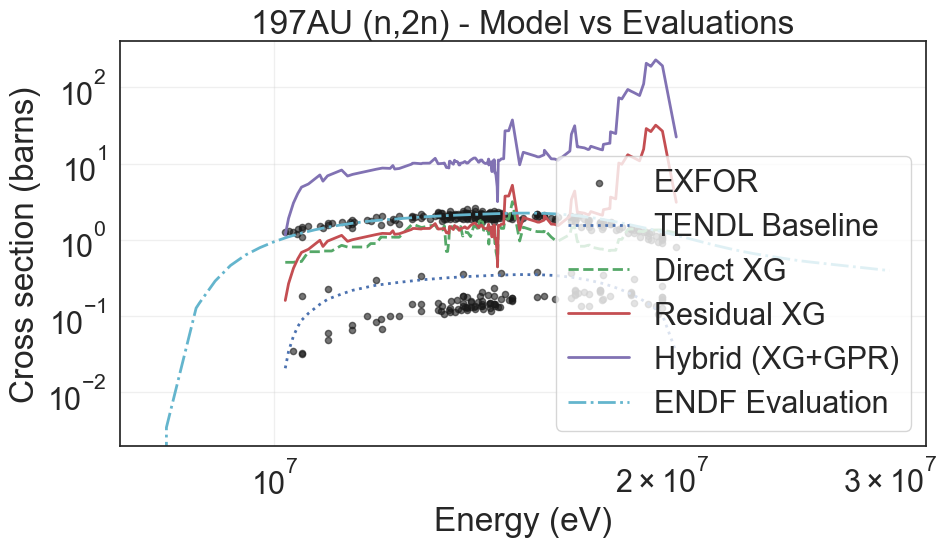

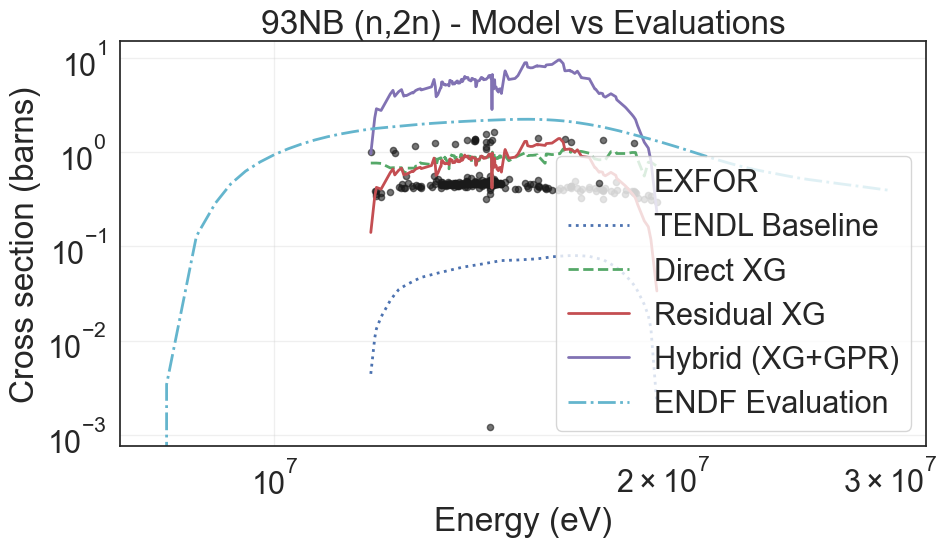

In [21]:
# Load evaluation libraries and merge into test_df
import matplotlib.pyplot as plt

# Load evaluations for test isotopes
eval_libs = {'endf': 'endfb8.0', 'jeff': 'jeff3.3', 'tendl': 'tendl.2019'}
eval_data = {lib: {} for lib in eval_libs}

#we load evaluated data like this 



for iso in test_isotopes:
    iso_name = iso.replace('-', '').lower()
    for lib_key, lib_name in eval_libs.items():
        try:
            df_eval = nuc_data.load_evaluation(iso_name, 16, library=lib_name)
            if df_eval is not None and not df_eval.empty:
                eval_data[lib_key][iso] = df_eval[['Energy', 'Data']].rename(columns={'Data': f'{lib_key}_val'})
        except:
            pass

# Merge evaluations into test_df
for lib_key in eval_libs:
    for iso in test_isotopes:
        if iso in eval_data[lib_key]:
            iso_test = test_df[test_df['Isotope_Norm'] == iso].copy()
            eval_df = eval_data[lib_key][iso]
            # Interpolate evaluation to test energies
            interp_vals = np.interp(np.log10(iso_test['Energy'] + 1e-10), 
                                     np.log10(eval_df['Energy'] + 1e-10), 
                                     eval_df[f'{lib_key}_val'])
            test_df.loc[iso_test.index, f'{lib_key}_val'] = interp_vals

# Plotting with evaluations (guarded with .get() for missing columns)
for iso in test_isotopes:
    iso_df = test_df[test_df['Isotope_Norm'] == iso].sort_values('Energy').copy()
    if iso_df.empty:
        print(f"No data for {iso}")
        continue
    
    # Predictions
    direct_log = model_direct.predict(iso_df[features])
    direct_pred = 10 ** direct_log
    
    xg_res = model_res.predict(iso_df[features])
    res_pred = iso_df['theory_val'].values * (10 ** xg_res)
    
    gpr_res, _ = gpr.predict(iso_df[features], return_std=True)
    hybrid_pred = iso_df['theory_val'].values * (10 ** (xg_res + gpr_res))
    
    true_vals = iso_df['Data'].values
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(iso_df['Energy'], true_vals, color='k', s=20, alpha=0.6, label='EXFOR')
    plt.plot(iso_df['Energy'], iso_df['theory_val'].values, 'b:', linewidth=2, label='TENDL Baseline')
    plt.plot(iso_df['Energy'], direct_pred, 'g--', linewidth=2, label='Direct XG')  
    plt.plot(iso_df['Energy'], res_pred, 'r-', linewidth=2, label='Residual XG')
    plt.plot(iso_df['Energy'], hybrid_pred, 'm-', linewidth=2, label='Hybrid (XG+GPR)')
    plt.plot(auendf['Energy'], auendf['Data'], 'c-.', linewidth=2, label='ENDF Evaluation')  # Example for Au197

    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)')
    plt.ylabel('Cross section (barns)')
    plt.title(f'{iso.upper()} (n,2n) - Model vs Evaluations')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
import seaborn as sns
import nucml.datasets as nuc_data
import logging

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

figure_dir = "figs2pres/" # saving directory


import nucml.evaluation.plot as eval_plot

In [39]:
import nucml.exfor.data_utilities as data_utils
exfordf=nuc_data.load_exfor()
exfordf.MT = exfordf.MT.astype(int)
figure_dir = "./testing/Figures/"


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names

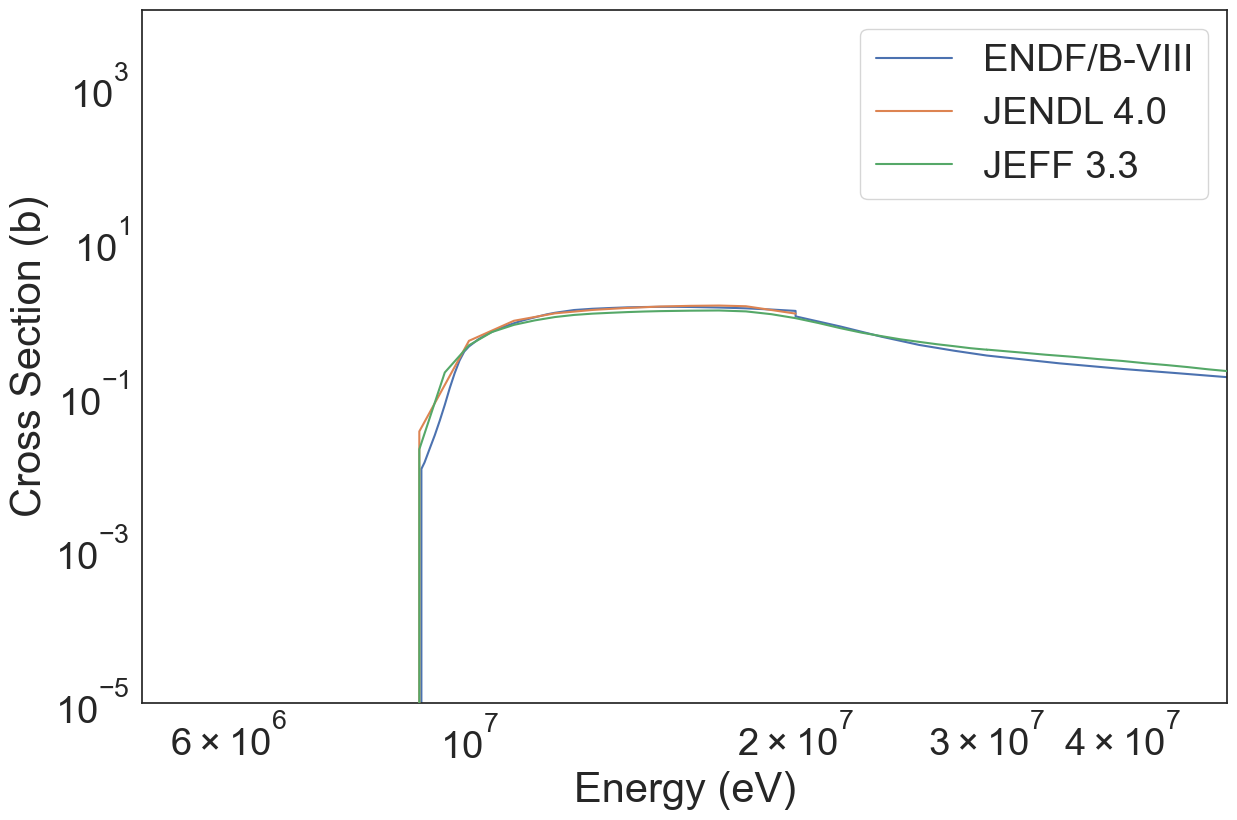

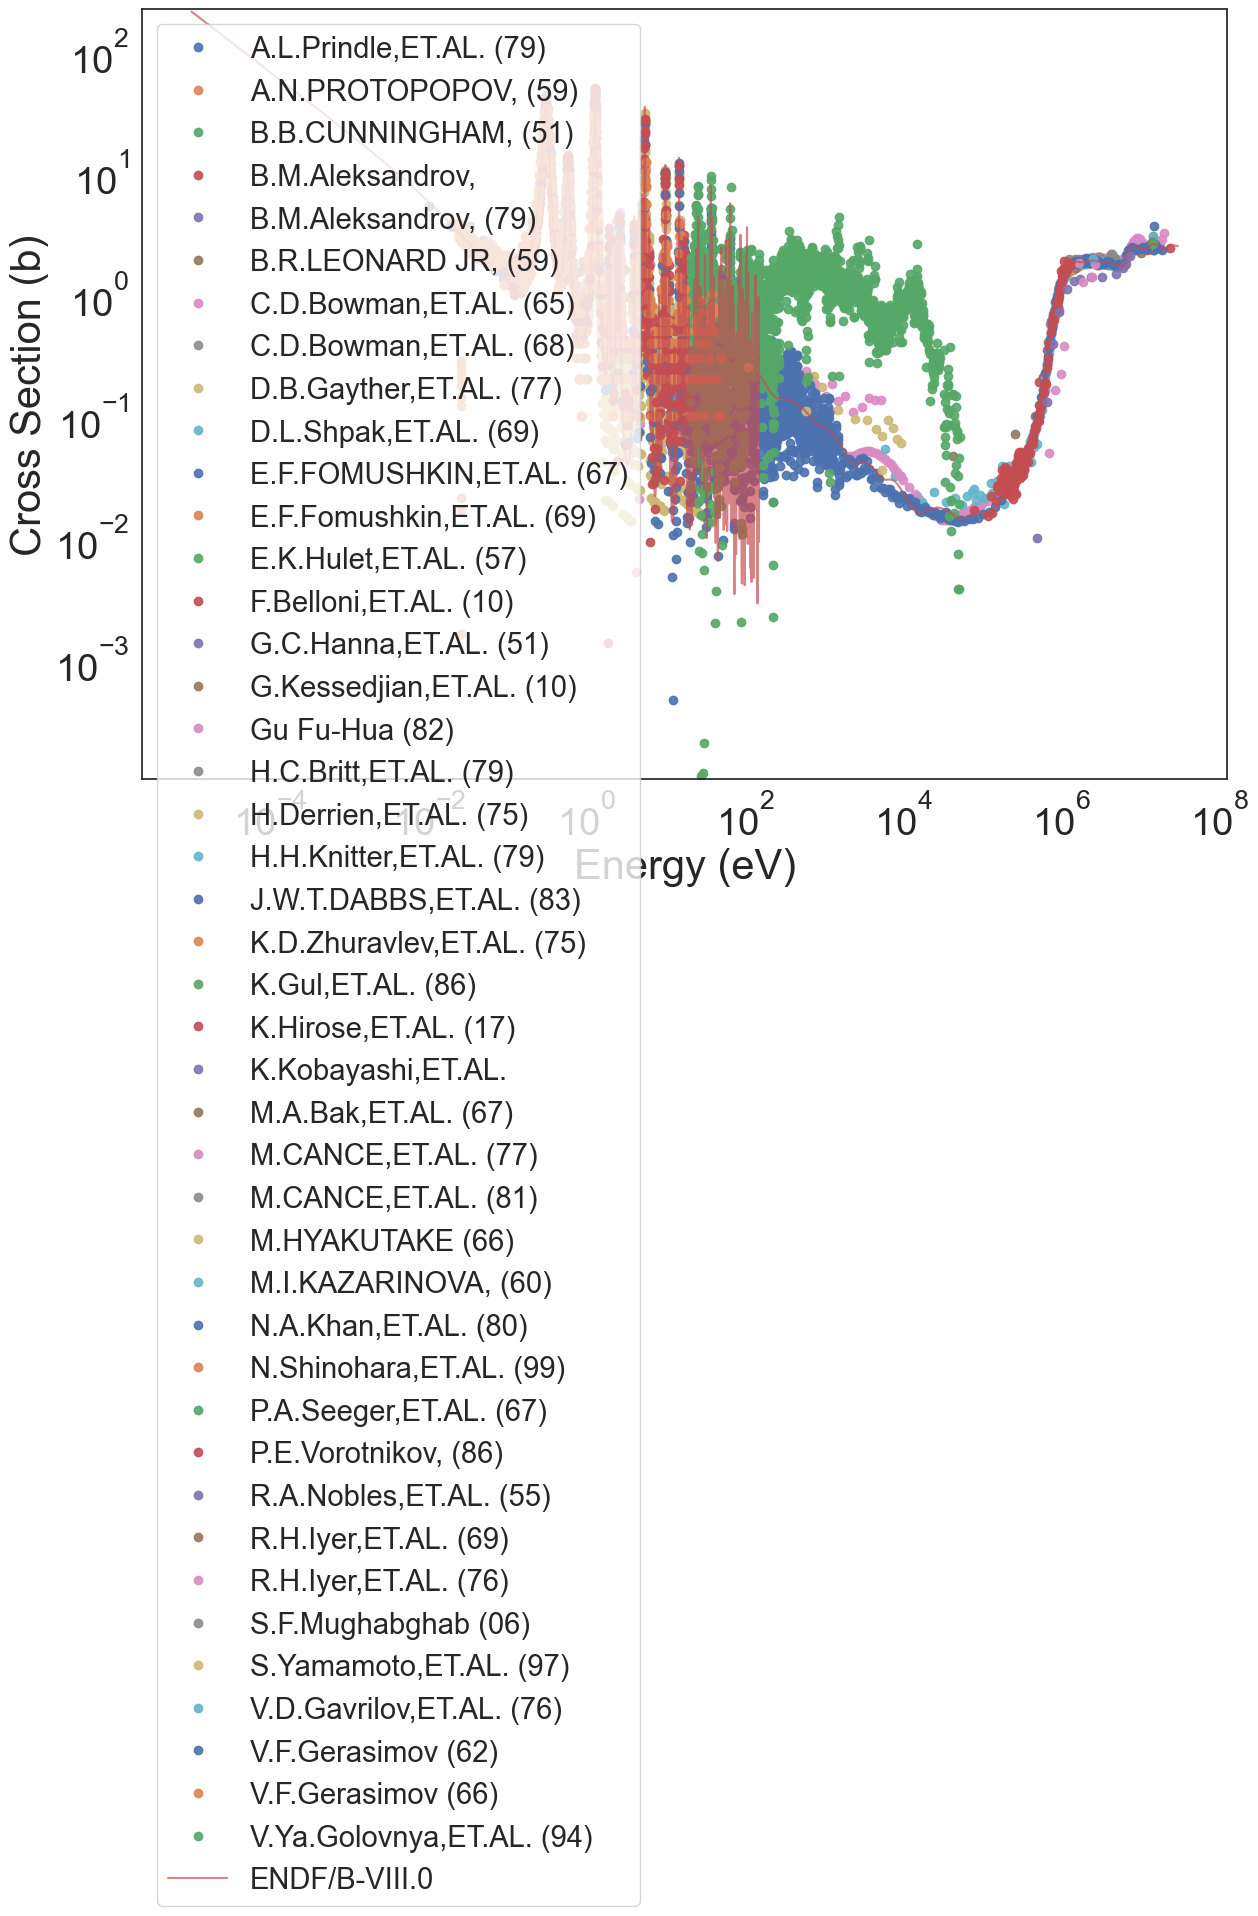

In [99]:


if not hasattr(pd.DataFrame, "append"):
    def _append(self, other, ignore_index=False, verify_integrity=False, sort=False):
        return pd.concat([self, other], ignore_index=ignore_index, verify_integrity=verify_integrity, sort=sort)
    pd.DataFrame.append = _append
kwargs = {"nat_iso":"I", "one_hot":False, "alpha":0.7, "legend":True, "interpolate":False, 
          "log_plot":True, "ref":True}


evalNb= eval_plot.plot("Nb93", 16, save=False, save_dir=figure_dir,exclude=['jendl4.0 ','tendl'])
plt.xlim(5e6, 5e7)
plt.ylim(1e-5, 1e4)
exforNb= data_utils.plot_exfor_w_references(exfordf, 95, 241, 18, get_endf=True, error=True, save=False, path=figure_dir, **kwargs)

In [71]:
exforNb[error]

NameError: name 'error' is not defined

In [46]:
#want same plot but with the evaluations plotted on top of the exfor data to compare how well the evaluations match the exfor data and to see if our models are doing better than the evaluations in terms of matching the exfor data need to extract from dictionary the evaluation data for the test isotopes and plot them on top of the exfor data to compare how well they match the exfor data and to see if our models are doing better than the evaluations in terms of matching the exfor data
from numpy import shape


print("exforNb type:", type(exforNb))
print("exforNb keys:", exforNb.keys() if isinstance(exforNb, dict) else "Not a dict")
if isinstance(exforNb, dict) and 'exfor' in exforNb:
    print(exforNb['exfor'].head())  

exforNb type: <class 'dict'>
exforNb keys: dict_keys(['exfor', 'endf', 'exfor_endf', 'error_metrics'])
        Projectile Target_Metastable_State  MT Product_Metastable_State        EXFOR_Status Center_of_Mass_Flag     Energy        dEnergy     Data     dData  ELV/HL  dELV/HL    I78            Short_Reference EXFOR_Accession_Number  EXFOR_SubAccession_Number EXFOR_Pointer   Z                     Reaction_Notation                                              Title  Year       Author Institute        Date                                          Reference Dataset_Number EXFOR_Entry                 Reference_Code  Projectile_Z  Projectile_A  Projectile_N Isotope Element   N   A Element_Flag  Nucleus_Radius  Neutron_Nucleus_Radius_Ratio      O  Mass_Excess  dMass_Excess  Binding_Energy  dBinding_Energy  B_Decay_Energy  dB_Decay_Energy  Atomic_Mass_Micro  dAtomic_Mass_Micro     S(2n)  dS(2n)     S(2p)  ...  dQ(2B-)    Q(ep)  dQ(ep)   Q(B-n)  dQ(B-n)     S(n)  dS(n)     S(p)  dS(p)    Q(4B-)

In [75]:
import nucml.model.utilities as model_utils  # Resolves the NameError
import nucml.datasets as nuc_data
import pandas as pd
import numpy as np

def get_error_tendl_exfor(tendl, exfor_sample):
    """
    Calculates error metrics between TENDL and EXFOR samples with safety floors.
    """
    tendl_copy = tendl.copy()
    exfor_copy = exfor_sample.copy()

    # 1. Aggressive Safety Floor to prevent log10(0) RuntimeWarnings
    # This must be done before passing to metrics utilities
    tendl_copy['Data'] = tendl_copy['Data'].clip(lower=1e-10)
    exfor_copy['Data'] = exfor_copy['Data'].clip(lower=1e-10)

    # 2. Unit alignment (MeV to eV if necessary)
    if exfor_copy['Energy'].max() > 1000 and tendl_copy['Energy'].max() < 1000:
        tendl_copy['Energy'] = tendl_copy['Energy'] * 1e6 

    # 3. Alignment Logic
    exfor_copy = exfor_copy[exfor_copy.Energy > tendl_copy.Energy.min()]
    
    # 4. Interpolation at exact experimental energy points
    theory_at_exp_points = np.interp(
        exfor_copy["Energy"].values, 
        tendl_copy["Energy"].values, 
        tendl_copy["Data"].values
    )

    # 5. Build the Aligned Dataframe
    exfor_tendl = pd.DataFrame({
        "Energy": exfor_copy.Energy.values,
        "EXFOR": exfor_copy["Data"].values,
        "TENDL": theory_at_exp_points
    })

    # 6. Calculate Metrics using nucml utilities
    # This now has access to 'model_utils'
    error_metrics = model_utils.regression_error_metrics(
        exfor_tendl["EXFOR"], 
        exfor_tendl["TENDL"]
    )
    
    # Creates the formatted error dataframe
    error_df = model_utils.create_error_df("EXFOR VS TENDL", error_metrics)

    return exfor_tendl, error_df

# --- Running the code ---
iso = "Nb93"
exfor_data_source = exforNb['exfor']

# Ensure iso_data is a DataFrame
iso_data = pd.DataFrame({
    'Energy': exfor_data_source['Energy'].values,
    'Data': exfor_data_source['Data'].values
})

try:
    tendl_raw = nuc_data.load_evaluation(iso, 16, library='tendl.2019')
    comparison_df, metrics = get_error_tendl_exfor(tendl_raw, iso_data)
    
    print(f"Metrics for {iso}:")
    print(metrics)
except Exception as e:
    print(f"Error: {e}")

Metrics for Nb93:
               id       mae      mse  evs   mae_m        r2
0  EXFOR VS TENDL  0.435311  0.26561  0.0  0.4481 -2.489607


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Inside your isotope loop:

iso= "Nb93"  # Example isotope, replace with your loop variable
exfor_data = exforNb['exfor']
iso_data = exfor_data['Energy'], exfor_data['Data']

new_evalNb=nuc_data.load_evaluation("Nb93", 16, library='endfb8.0',)
print(new_evalNb.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNb['Energy'] = 10 ** new_evalNb['Energy']
new_evalNb['Data'] = 10 ** new_evalNb['Data']
print(new_evalNb.head())
import nucml.evaluation.plot as eval_plot

eval_plot.plot("Nb93", 16, save=True, save_dir=figure_dir)

new_evalNbTheory=nuc_data.load_evaluation("Nb93", 16, library='tendl.2019',)
print(new_evalNbTheory.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNbTheory['Energy'] = 10 ** new_evalNbTheory['Energy']
new_evalNbTheory['Data'] = 10 ** new_evalNbTheory['Data']
print(new_evalNbTheory.head())


try:
    # 1. Load the raw TENDL evaluation
    tendl_raw = nuc_data.load_evaluation(iso, 16, library='tendl.2019')
    
    # 2. Run the new error function
    comparison_df, metrics = get_error_tendl_exfor(tendl_raw, iso_data)
    
    print(f"Metrics for {iso}:")
    print(metrics)
except Exception as e:
    print(f"Error calculating TENDL metrics: {e}")

Error calculating TENDL metrics: 'tuple' object has no attribute 'copy'


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarn

     Energy      Data
0  6.950803      -inf
1  6.956168 -1.966576
2  6.957080 -1.939302
3  6.959041 -1.882729
4  6.963788 -1.703335
      Energy    Data
0  8929000.0  0.0000
1  9040000.0  0.0108
2  9059000.0  0.0115
3  9100000.0  0.0131
4  9200000.0  0.0198


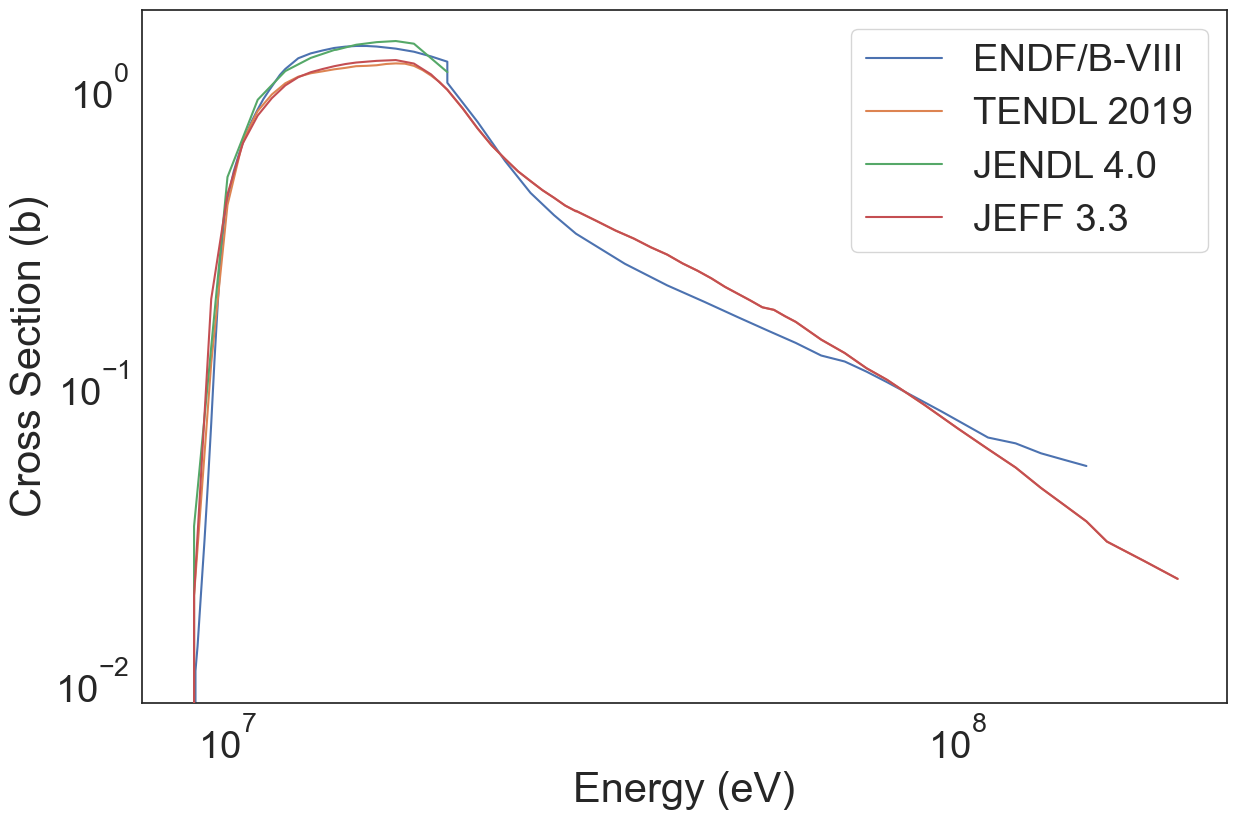

In [ ]:
new_evalNb=nuc_data.load_evaluation("Nb93", 16, library='endfb8.0',)
print(new_evalNb.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNb['Energy'] = 10 ** new_evalNb['Energy']
new_evalNb['Data'] = 10 ** new_evalNb['Data']
print(new_evalNb.head())
import nucml.evaluation.plot as eval_plot

eval_plot.plot("Nb93", 16, save=True, save_dir=figure_dir)

In [ ]:
new_evalNb=nuc_data.load_evaluation("Nb93", 16, library='endfb8.0',)
print(new_evalNb.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNb['Energy'] = 10 ** new_evalNb['Energy']
new_evalNb['Data'] = 10 ** new_evalNb['Data']
print(new_evalNb.head())
import nucml.evaluation.plot as eval_plot

eval_plot.plot("Nb93", 16, save=True, save_dir=figure_dir)

new_evalNbTheory=nuc_data.load_evaluation("Nb93", 16, library='tendl.2019',)
print(new_evalNbTheory.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNbTheory['Energy'] = 10 ** new_evalNbTheory['Energy']
new_evalNbTheory['Data'] = 10 ** new_evalNbTheory['Data']
print(new_evalNbTheory.head())

     Energy      Data
0  6.950693      -inf
1  6.954243 -1.711176
2  6.977724 -0.929936
3  7.000000 -0.397066
4  7.021189 -0.179806
       Energy      Data
0   8926740.0  0.000000
1   9000000.0  0.019446
2   9500000.0  0.117507
3  10000000.0  0.400806
4  10500000.0  0.660988


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:

exforNb= data_utils.plot_exfor_w_references(exfordf, 41, 93, 16, get_endf=True, error=True, save=False, path=figure_dir, **kwargs)
iso= "Nb93"  # Example isotope, replace with your loop variable
exfor_data = exforNb['exfor']
iso_data = exfor_data['Energy'], exfor_data['Data']

new_evalNb=nuc_data.load_evaluation("Nb93", 16, library='endfb8.0',)
print(new_evalNb.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNb['Energy'] = 10 ** new_evalNb['Energy']
new_evalNb['Data'] = 10 ** new_evalNb['Data']
print(new_evalNb.head())
import nucml.evaluation.plot as eval_plot

eval_plot.plot("Nb93", 16, save=True, save_dir=figure_dir)

new_evalNbTheory=nuc_data.load_evaluation("Nb93", 16, library='tendl.2019',)
print(new_evalNbTheory.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalNbTheory['Energy'] = 10 ** new_evalNbTheory['Energy']
new_evalNbTheory['Data'] = 10 ** new_evalNbTheory['Data']
print(new_evalNbTheory.head())





            Energy     S(2n)
2105047  8920000.0  16717.47
2105050  9000000.0  16717.47
2105065  9020000.0  16717.47
2105083  9090000.0  16717.47
2105220  9135000.0  16717.47


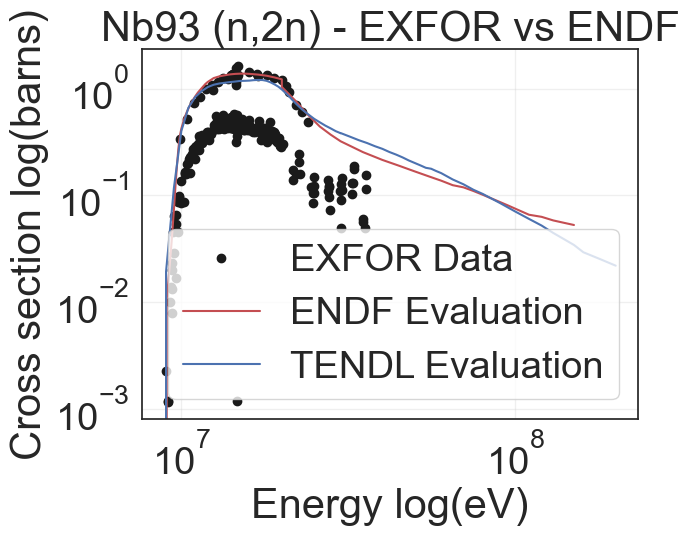

In [67]:
#with above output to print just the energy and cross section values for the exfor data to compare with the evaluations and our model predictions
if isinstance(exforNb, dict) and 'exfor' in exforNb:
    exfor_data = exforNb['exfor']
    print(exfor_data[['Energy', 'S(2n)']].head())

plt.plot(exfor_data['Energy'], exfor_data['Data'], 'ko', label='EXFOR Data')
plt.plot(new_evalNb['Energy'], new_evalNb['Data'], 'r-', label='ENDF Evaluation')
plt.plot(new_evalNbTheory['Energy'], new_evalNbTheory['Data'], 'b-', label='TENDL Evaluation')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy log(eV)')
plt.ylabel('Cross section log(barns)')
plt.title('Nb93 (n,2n) - EXFOR vs ENDF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
tendlau197=nuc_data.load_evaluation("au197", 16, library='tendl.2019')
endfau197=nuc_data.load_evaluation("au197", 16)
tendlau197.head()
print("\nENDF Evaluation for Au197 (n,2n):")
endfau197.head()


ENDF Evaluation for Au197 (n,2n):


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: Run

,Energy,Data
0,6.908523,-inf
1,6.916454,-2.463397
2,6.939474,-0.896809
3,6.942008,-0.831034
4,6.954243,-0.541362


In [77]:
import nucml.exfor.data_utilities as data_utils

data_utils.get_error_endf_exfor(new_evalNb, exforNb['exfor'])

(         Energy    EXFOR      ENDF
 0     9000000.0  0.00230  0.003600
 1     9020000.0  0.00000  0.007200
 2     9090000.0  0.00120  0.012300
 3     9135000.0  0.00118  0.016450
 4     9250000.0  0.01000  0.024700
 ..          ...      ...       ...
 366  35000000.0  0.06060  0.266449
 367  35000000.0  0.05639  0.260369
 368  35500000.0  0.05000  0.244484
 369  35625000.0  0.11540  0.224873
 370  35625000.0  0.15498  0.234679
 
 [371 rows x 3 columns],
               id       mae       mse       evs     mae_m        r2
 0  EXFOR VS ENDF  0.690927  0.580955 -0.438012  0.873439 -6.663543)

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nucml.datasets as nuc_data

def overlay_exfor_evaluations(isotope, mt_number, exfordf, figure_dir="./figures/", 
                               libraries=['tendl.2019', 'endfb8.0'], **kwargs):
    """
    Overlay EXFOR experimental data with theoretical evaluations (TENDL, ENDF).
    Handles unit conversions and interpolation automatically.
    
    Parameters:
    -----------
    isotope : str
        Isotope name (e.g., "Nb93", "Au197")
    mt_number : int
        MT reaction number (e.g., 16 for n,2n)
    exfordf : pd.DataFrame
        EXFOR dataframe from nuc_data.load_exfor()
    figure_dir : str
        Directory to save figures
    libraries : list
        List of evaluation libraries to load
    **kwargs : dict
        Additional plotting arguments
    
    Returns:
    --------
    dict : Contains 'exfor', 'evaluations' (dict of library data), and error metrics
    """
    
    # Extract isotope parameters
    z, a = _parse_isotope(isotope)
    iso_norm = isotope.lower().replace('-', '').strip()
    
    # 1. Load EXFOR data
    exfor_data = exfordf[
        (exfordf['Z'] == z) & 
        (exfordf['A'] == a) & 
        (exfordf['MT'].astype(float) == float(mt_number))
    ].copy()
    
    if exfor_data.empty:
        print(f"No EXFOR data found for {isotope} MT={mt_number}")
        return None
    
    exfor_data = exfor_data[['Energy', 'Data']].copy()
    exfor_data['Energy'] = exfor_data['Energy'].astype(float)
    exfor_data['Data'] = exfor_data['Data'].astype(float)
    exfor_data = exfor_data.dropna()
    
    # 2. Load evaluations
    eval_dict = {}
    for lib in libraries:
        try:
            eval_df = nuc_data.load_evaluation(iso_norm, mt_number, library=lib)
            if eval_df is not None and not eval_df.empty:
                eval_df = eval_df[['Energy', 'Data']].copy()
                # Convert from log10(eV) and log10(barns) to linear space
                eval_df['Energy'] = 10 ** eval_df['Energy']
                eval_df['Data'] = 10 ** eval_df['Data']
                eval_dict[lib] = eval_df.dropna()
        except Exception as e:
            print(f"Could not load {lib} for {isotope}: {e}")
    
    # 3. Interpolate evaluations to EXFOR energy points
    interp_dict = {}
    for lib_name, lib_data in eval_dict.items():
        interp_vals = np.interp(
            exfor_data['Energy'].values,
            lib_data['Energy'].values,
            lib_data['Data'].values,
            left=np.nan,
            right=np.nan
        )
        interp_dict[lib_name] = interp_vals
    
    # 4. Calculate error metrics
    metrics = {}
    for lib_name, interp_vals in interp_dict.items():
        valid = ~np.isnan(interp_vals)
        if valid.sum() > 0:
            exp_vals = exfor_data['Data'].values[valid]
            th_vals = interp_vals[valid]
            metrics[lib_name] = _calculate_error_metrics(exp_vals, th_vals)
    
    # 5. Create comparison dataframe
    comparison_df = exfor_data.copy()
    for lib_name, interp_vals in interp_dict.items():
        comparison_df[f'{lib_name}_pred'] = interp_vals
    
    # 6. Plotting
    plt.figure(figsize=(12, 7))
    
    # EXFOR scatter
    plt.scatter(exfor_data['Energy'], exfor_data['Data'], 
                color='black', s=50, alpha=0.6, label='EXFOR', zorder=5)
    
    # Evaluation lines
    colors = {'tendl.2019': 'blue', 'endfb8.0': 'red', 'jeff3.3': 'green', 'jendl5.0': 'purple'}
    for lib_name, lib_data in eval_dict.items():
        color = colors.get(lib_name, 'gray')
        label = lib_name.upper()
        if lib_name in metrics:
            label += f" (RMSE={metrics[lib_name]['rmse']:.3f})"
        plt.plot(lib_data['Energy'], lib_data['Data'], 
                color=color, linewidth=2, label=label, alpha=0.8)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)', fontsize=12)
    plt.ylabel('Cross Section (barns)', fontsize=12)
    plt.title(f'{isotope.upper()} (n,2n) - EXFOR vs Evaluations', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    import os
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f'{iso_norm}_overlay.png'), dpi=300)
    plt.show()
    
    return {
        'exfor': exfor_data,
        'evaluations': eval_dict,
        'interpolated': interp_dict,
        'comparison': comparison_df,
        'metrics': metrics
    }


def _parse_isotope(isotope_str):
    """Extract Z and A from isotope string like 'Nb93' or 'Au197'."""
    import re
    match = re.match(r'([A-Z][a-z]?)(\d+)', isotope_str)
    if not match:
        raise ValueError(f"Invalid isotope format: {isotope_str}")
    
    element_map = {
        'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8,
        'F': 9, 'Ne': 10, 'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15,
        'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19, 'Ca': 20, 'Sc': 21, 'Ti': 22,
        'V': 23, 'Cr': 24, 'Mn': 25, 'Fe': 26, 'Co': 27, 'Ni': 28, 'Cu': 29,
        'Zn': 30, 'Ga': 31, 'Ge': 32, 'As': 33, 'Se': 34, 'Br': 35, 'Kr': 36,
        'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40, 'Nb': 41, 'Mo': 42, 'Tc': 43,
        'Ru': 44, 'Rh': 45, 'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50,
        'Sb': 51, 'Te': 52, 'I': 53, 'Xe': 54, 'Cs': 55, 'Ba': 56, 'La': 57,
        'Ce': 58, 'Pr': 59, 'Nd': 60, 'Pm': 61, 'Sm': 62, 'Eu': 63, 'Gd': 64,
        'Tb': 65, 'Dy': 66, 'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70, 'Lu': 71,
        'Hf': 72, 'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77, 'Pt': 78,
        'Au': 79, 'Hg': 80, 'Tl': 81, 'Pb': 82, 'Bi': 83, 'Po': 84, 'At': 85,
        'Rn': 86, 'Fr': 87, 'Ra': 88, 'Ac': 89, 'Th': 90, 'Pa': 91, 'U': 92
    }
    
    element, a = match.groups()
    z = element_map.get(element)
    if z is None:
        raise ValueError(f"Unknown element: {element}")
    
    return z, int(a)


def _calculate_error_metrics(experimental, theoretical):
    """Calculate standard error metrics."""
    exp = np.array(experimental, dtype=float)
    th = np.array(theoretical, dtype=float)
    
    valid = (exp > 0) & (th > 0) & ~np.isnan(exp) & ~np.isnan(th)
    if not valid.any():
        return {'rmse': np.nan, 'mape': np.nan}
    
    exp = exp[valid]
    th = th[valid]
    
    rmse = np.sqrt(np.mean((exp - th) ** 2))
    mape = np.mean(np.abs((exp - th) / exp)) * 100
    
    return {'rmse': rmse, 'mape': mape}

In [89]:
def _parse_isotope(isotope_str):
    """Extract Z and A from isotope string like 'Nb93' or 'Au197' or '226Ra'."""
    import re
    match = re.match(r'([A-Z][a-z]?)(\d+)', isotope_str)
    if not match:
        raise ValueError(f"Invalid isotope format: {isotope_str}")
    
    element_map = {
        'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8,
        'F': 9, 'Ne': 10, 'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15,
        'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19, 'Ca': 20, 'Sc': 21, 'Ti': 22,
        'V': 23, 'Cr': 24, 'Mn': 25, 'Fe': 26, 'Co': 27, 'Ni': 28, 'Cu': 29,
        'Zn': 30, 'Ga': 31, 'Ge': 32, 'As': 33, 'Se': 34, 'Br': 35, 'Kr': 36,
        'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40, 'Nb': 41, 'Mo': 42, 'Tc': 43,
        'Ru': 44, 'Rh': 45, 'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50,
        'Sb': 51, 'Te': 52, 'I': 53, 'Xe': 54, 'Cs': 55, 'Ba': 56, 'La': 57,
        'Ce': 58, 'Pr': 59, 'Nd': 60, 'Pm': 61, 'Sm': 62, 'Eu': 63, 'Gd': 64,
        'Tb': 65, 'Dy': 66, 'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70, 'Lu': 71,
        'Hf': 72, 'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77, 'Pt': 78,
        'Au': 79, 'Hg': 80, 'Tl': 81, 'Pb': 82, 'Bi': 83, 'Po': 84, 'At': 85,
        'Rn': 86, 'Fr': 87, 'Ra': 88, 'Ac': 89, 'Th': 90, 'Pa': 91, 'U': 92,
        'Np': 93, 'Pu': 94, 'Am': 95, 'Cm': 96, 'Bk': 97, 'Cf': 98, 'Es': 99,
        'Fm': 100, 'Md': 101, 'No': 102, 'Lr': 103, 'Rf': 104, 'Db': 105,
        'Sg': 106, 'Bh': 107, 'Hs': 108, 'Mt': 109, 'Ds': 110, 'Rg': 111,
        'Cn': 112, 'Nh': 113, 'Fl': 114, 'Mc': 115, 'Lv': 116, 'Ts': 117, 'Og': 118
    }
    
    element, a = match.groups()
    z = element_map.get(element)
    if z is None:
        raise ValueError(f"Unknown element: {element}")
    
    return int(z), int(a)


def _calculate_error_metrics(experimental, theoretical):
    """Calculate standard error metrics."""
    exp = np.array(experimental, dtype=float)
    th = np.array(theoretical, dtype=float)
    
    valid = (exp > 0) & (th > 0) & ~np.isnan(exp) & ~np.isnan(th)
    if not valid.any():
        return {'rmse': np.nan, 'mape': np.nan}
    
    exp = exp[valid]
    th = th[valid]
    
    rmse = np.sqrt(np.mean((exp - th) ** 2))
    mape = np.mean(np.abs((exp - th) / exp)) * 100
    
    return {'rmse': rmse, 'mape': mape}


# filepath: /Users/glsw/main/n-2nDTautofeature.ipynb
def overlay_exfor_evaluations(isotope=None, z=None, a=None, mt_number=16, exfordf=None, 
                               figure_dir="./figures/", libraries=['tendl.2019', 'endfb8.0'], **kwargs):
    """
    Overlay EXFOR experimental data with theoretical evaluations.
    """
    import os
    
    # Parse isotope if not explicitly provided
    if z is None or a is None:
        if isotope is None:
            raise ValueError("Must provide either 'isotope' string or both 'z' and 'a'")
        
        try:
            z, a = _parse_isotope(isotope)
            iso_norm = isotope.lower().replace('-', '').strip()
            print(f"✓ Parsed {isotope} → Z={z}, A={a}")
        except ValueError as e:
            print(f"✗ {e}")
            return None
    else:
        iso_norm = isotope.lower().replace('-', '').strip() if isotope else f"z{z}a{a}"
    
    # 1. Load EXFOR data
    exfor_data = exfordf[
        (exfordf['Z'] == z) & 
        (exfordf['A'] == a) & 
        (exfordf['MT'].astype(float) == float(mt_number))
    ].copy()
    
    if exfor_data.empty:
        print(f"✗ No EXFOR data for Z={z}, A={a}, MT={mt_number}")
        return None
    
    exfor_data = exfor_data[['Energy', 'Data']].copy()
    exfor_data['Energy'] = exfor_data['Energy'].astype(float)
    exfor_data['Data'] = exfor_data['Data'].astype(float)
    exfor_data = exfor_data.dropna()
    print(f"✓ Found {len(exfor_data)} EXFOR points")
    
    # 2. Load evaluations
    eval_dict = {}
    for lib in libraries:
        try:
            eval_df = nuc_data.load_evaluation(iso_norm, mt_number, library=lib)
            if eval_df is not None and not eval_df.empty:
                # Select only Energy and Data columns
                eval_df = eval_df[['Energy', 'Data']].copy()
                # Convert from log space
                eval_df['Energy'] = 10 ** eval_df['Energy']
                eval_df['Data'] = 10 ** eval_df['Data'].clip(lower=1e-15)
                eval_dict[lib] = eval_df.dropna()
                print(f"✓ Loaded {lib}: {len(eval_df)} points")
        except Exception as e:
            print(f"✗ Could not load {lib}: {str(e)[:60]}")
    
    if not eval_dict:
        print("No evaluations loaded!")
        return None
    
    # 3. Interpolate evaluations to EXFOR energy points
    interp_dict = {}
    for lib_name, lib_data in eval_dict.items():
        interp_vals = np.interp(
            exfor_data['Energy'].values,
            lib_data['Energy'].values,
            lib_data['Data'].values,
            left=np.nan,
            right=np.nan
        )
        interp_dict[lib_name] = interp_vals
    
    # 4. Calculate error metrics
    metrics = {}
    for lib_name, interp_vals in interp_dict.items():
        valid = ~np.isnan(interp_vals)
        if valid.sum() > 0:
            exp_vals = exfor_data['Data'].values[valid]
            th_vals = interp_vals[valid]
            metrics[lib_name] = _calculate_error_metrics(exp_vals, th_vals)
    
    # 5. Create comparison dataframe
    comparison_df = exfor_data.copy()
    for lib_name, interp_vals in interp_dict.items():
        comparison_df[f'{lib_name}_pred'] = interp_vals
    
    # 6. Plotting
    plt.figure(figsize=(12, 7))
    plt.scatter(exfor_data['Energy'], exfor_data['Data'], 
                color='black', s=50, alpha=0.6, label='EXFOR', zorder=5)
    
    colors = {'tendl.2019': 'blue', 'endfb8.0': 'red', 'jeff3.3': 'green', 'jendl5.0': 'purple'}
    for lib_name, lib_data in eval_dict.items():
        color = colors.get(lib_name, 'gray')
        label = lib_name.upper()
        if lib_name in metrics:
            label += f" (RMSE={metrics[lib_name]['rmse']:.3e})"
        plt.plot(lib_data['Energy'], lib_data['Data'], 
                color=color, linewidth=2, label=label, alpha=0.8)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)', fontsize=12)
    plt.ylabel('Cross Section (barns)', fontsize=12)
    plt.title(f'Z={z}, A={a} MT={mt_number} - EXFOR vs Evaluations', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f'{iso_norm}_mt{mt_number}_overlay.png'), dpi=300)
    plt.show()
    
    return {
        'exfor': exfor_data,
        'evaluations': eval_dict,
        'interpolated': interp_dict,
        'comparison': comparison_df,
        'metrics': metrics,
        'z': z,
        'a': a
    }

In [90]:
def overlay_exfor_evaluations(isotope=None, z=None, a=None, mt_number=16, exfordf=None, 
                               figure_dir="./figures/", libraries=['tendl.2019', 'endfb8.0'], **kwargs):
    """
    Overlay EXFOR experimental data with theoretical evaluations (TENDL, ENDF).
    Handles unit conversions and interpolation automatically.
    
    Parameters:
    -----------
    isotope : str, optional
        Isotope name (e.g., "Nb93", "Au197", "226Ra")
    z : int, optional
        Atomic number (if isotope parsing fails, provide this)
    a : int, optional
        Mass number (if isotope parsing fails, provide this)
    mt_number : int
        MT reaction number (e.g., 16 for n,2n)
    exfordf : pd.DataFrame
        EXFOR dataframe from nuc_data.load_exfor()
    figure_dir : str
        Directory to save figures
    libraries : list
        List of evaluation libraries to load
    **kwargs : dict
        Additional plotting arguments
    
    Returns:
    --------
    dict : Contains 'exfor', 'evaluations', 'interpolated', 'comparison', and 'metrics'
    """
    import os
    
    # Try to parse isotope if not explicitly provided
    if z is None or a is None:
        if isotope is None:
            raise ValueError("Must provide either 'isotope' string or both 'z' and 'a' separately")
        
        try:
            z, a = _parse_isotope(isotope)
            iso_norm = isotope.lower().replace('-', '').strip()
            print(f"Parsed {isotope} → Z={z}, A={a}")
        except ValueError as e:
            print(f"Error parsing isotope: {e}")
            print("Please provide Z and A separately:")
            z = int(input("Enter atomic number (Z): "))
            a = int(input("Enter mass number (A): "))
            iso_norm = isotope.lower().replace('-', '').strip() if isotope else f"z{z}a{a}"
    else:
        iso_norm = isotope.lower().replace('-', '').strip() if isotope else f"z{z}a{a}"
    
    # 1. Load EXFOR data
    exfor_data = exfordf[
        (exfordf['Z'] == z) & 
        (exfordf['A'] == a) & 
        (exfordf['MT'].astype(float) == float(mt_number))
    ].copy()
    
    if exfor_data.empty:
        print(f"No EXFOR data found for Z={z}, A={a}, MT={mt_number}")
        return None
    
    exfor_data = exfor_data[['Energy', 'Data']].copy()
    exfor_data['Energy'] = exfor_data['Energy'].astype(float)
    exfor_data['Data'] = exfor_data['Data'].astype(float)
    exfor_data = exfor_data.dropna()
    
    print(f"Found {len(exfor_data)} EXFOR data points")
    
    # # 2. Load evaluations
    # eval_dict = {}
    # for lib in libraries:
    #     try:
    #         eval_df = nuc_data.load_evaluation(iso_norm, mt_number, library=lib)
    #         if eval_df is not None and not eval_df.empty:
    #             eval_df = eval_df[['Energy', 'Data']].copy()
    #             # Convert from log10(eV) and log10(barns) to linear space
    #             eval_df['Energy'] = 10 ** eval_df['Energy']
    #             eval_df['Data'] = 10 ** eval_df['Data']
    #             eval_dict[lib] = eval_df.dropna()
    #             print(f"Loaded {lib}: {len(eval_df)} points")
    #     except Exception as e:
    #         print(f"Could not load {lib}: {e}")
    
    # 2. Load evaluations
    eval_dict = {}
    for lib in libraries:
        try:
            eval_df = nuc_data.load_evaluation(iso_norm, mt_number, library=lib)
            if eval_df is not None and not eval_df.empty:
            # Keep only Energy and Data columns, rename if needed
                if 'Energy' in eval_df.columns and 'Data' in eval_df.columns:
                    eval_df = eval_df[['Energy', 'Data']].copy()
                else:
                # Handle case where columns might have different names
                    print(f"Available columns in {lib}: {eval_df.columns.tolist()}")
                    continue
            
            # Convert from log10(eV) and log10(barns) to linear space
                eval_df['Energy'] = 10 ** eval_df['Energy']
                eval_df['Data'] = 10 ** eval_df['Data']
                eval_dict[lib] = eval_df.dropna()
                print(f"Loaded {lib}: {len(eval_df)} points")
        except Exception as e:
            print(f"Could not load {lib}: {e}")


    # 3. Interpolate evaluations to EXFOR energy points
    interp_dict = {}
    for lib_name, lib_data in eval_dict.items():
        interp_vals = np.interp(
            exfor_data['Energy'].values,
            lib_data['Energy'].values,
            lib_data['Data'].values,
            left=np.nan,
            right=np.nan
        )
        interp_dict[lib_name] = interp_vals
    
    # 4. Calculate error metrics
    metrics = {}
    for lib_name, interp_vals in interp_dict.items():
        valid = ~np.isnan(interp_vals)
        if valid.sum() > 0:
            exp_vals = exfor_data['Data'].values[valid]
            th_vals = interp_vals[valid]
            metrics[lib_name] = _calculate_error_metrics(exp_vals, th_vals)
    
    # 5. Create comparison dataframe
    comparison_df = exfor_data.copy()
    for lib_name, interp_vals in interp_dict.items():
        comparison_df[f'{lib_name}_pred'] = interp_vals
    
    # 6. Plotting
    plt.figure(figsize=(12, 7))
    
    # EXFOR scatter
    plt.scatter(exfor_data['Energy'], exfor_data['Data'], 
                color='black', s=50, alpha=0.6, label='EXFOR', zorder=5)
    
    # Evaluation lines
    colors = {'tendl.2019': 'blue', 'endfb8.0': 'red', 'jeff3.3': 'green', 'jendl5.0': 'purple'}
    for lib_name, lib_data in eval_dict.items():
        color = colors.get(lib_name, 'gray')
        label = lib_name.upper()
        if lib_name in metrics:
            label += f" (RMSE={metrics[lib_name]['rmse']:.3f})"
        plt.plot(lib_data['Energy'], lib_data['Data'], 
                color=color, linewidth=2, label=label, alpha=0.8)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (eV)', fontsize=12)
    plt.ylabel('Cross Section (barns)', fontsize=12)
    plt.title(f'Z={z}, A={a} (n,2n) - EXFOR vs Evaluations', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f'{iso_norm}_overlay.png'), dpi=300)
    plt.show()
    
    return {
        'exfor': exfor_data,
        'evaluations': eval_dict,
        'interpolated': interp_dict,
        'comparison': comparison_df,
        'metrics': metrics,
        'z': z,
        'a': a
    }

In [91]:
eval_test = nuc_data.load_evaluation("nb93", 16, library='endfb8.0')
print("Columns:", eval_test.columns.tolist())
print(eval_test.head())

Columns: ['Energy', 'Data']
     Energy      Data
0  6.950803      -inf
1  6.956168 -1.966576
2  6.957080 -1.939302
3  6.959041 -1.882729
4  6.963788 -1.703335


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Found 135543 EXFOR data points
Could not load tendl.2019: too many values to unpack (expected 2)
Could not load endfb8.0: too many values to unpack (expected 2)


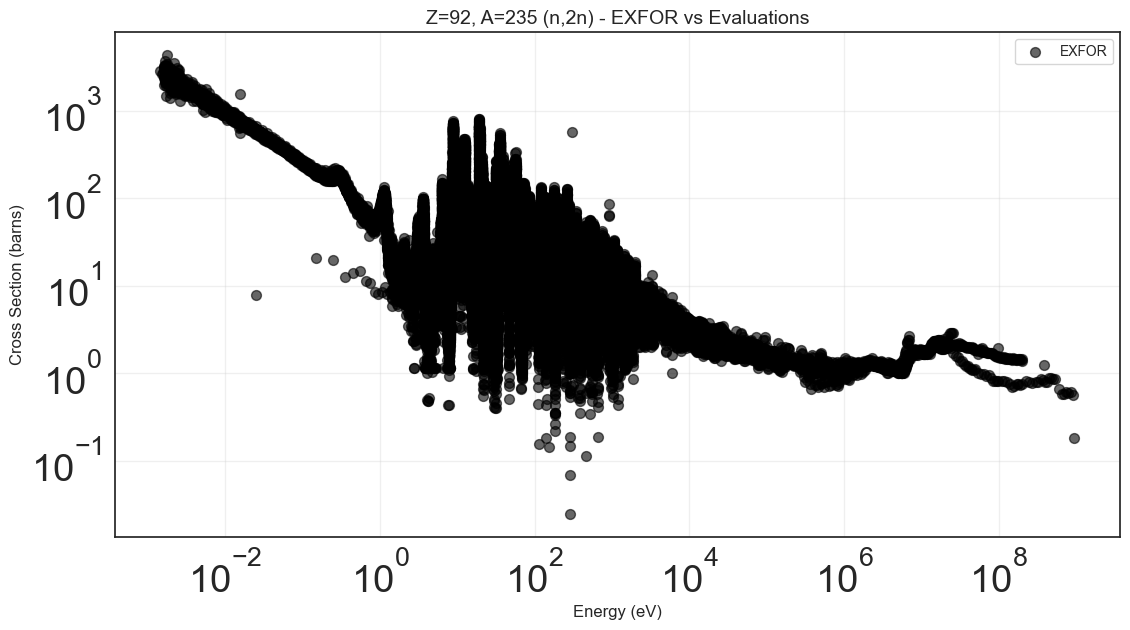

{'exfor':               Energy  Data
 3371022          0.0  2.70
 3371023     100000.0  1.55
 3371024     200000.0  1.40
 3371025     300000.0  1.40
 3371026     400000.0  1.29
 ...              ...   ...
 3506560   96500000.0  1.93
 3506561  147000000.0  1.40
 3506562  199000000.0  1.38
 3506563  120000000.0  1.50
 3506564  380000000.0  1.24
 
 [135543 rows x 2 columns],
 'evaluations': {},
 'interpolated': {},
 'comparison':               Energy  Data
 3371022          0.0  2.70
 3371023     100000.0  1.55
 3371024     200000.0  1.40
 3371025     300000.0  1.40
 3371026     400000.0  1.29
 ...              ...   ...
 3506560   96500000.0  1.93
 3506561  147000000.0  1.40
 3506562  199000000.0  1.38
 3506563  120000000.0  1.50
 3506564  380000000.0  1.24
 
 [135543 rows x 2 columns],
 'metrics': {},
 'z': 92,
 'a': 235}

In [92]:
overlay_exfor_evaluations(z=92,a=235, mt_number=18, exfordf=exfordf, figure_dir="./figures/", 
                               libraries=['tendl.2019', 'endfb8.0'], **kwargs)

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names

     Energy      Data
0 -5.000000  2.326535
1 -4.986224  2.319643
2 -4.972451  2.312755
3 -4.958670  2.305863
4 -4.944901  2.298975
     Energy     Data
0  0.000010  212.097
1  0.000010  208.758
2  0.000011  205.473
3  0.000011  202.238
4  0.000011  199.056


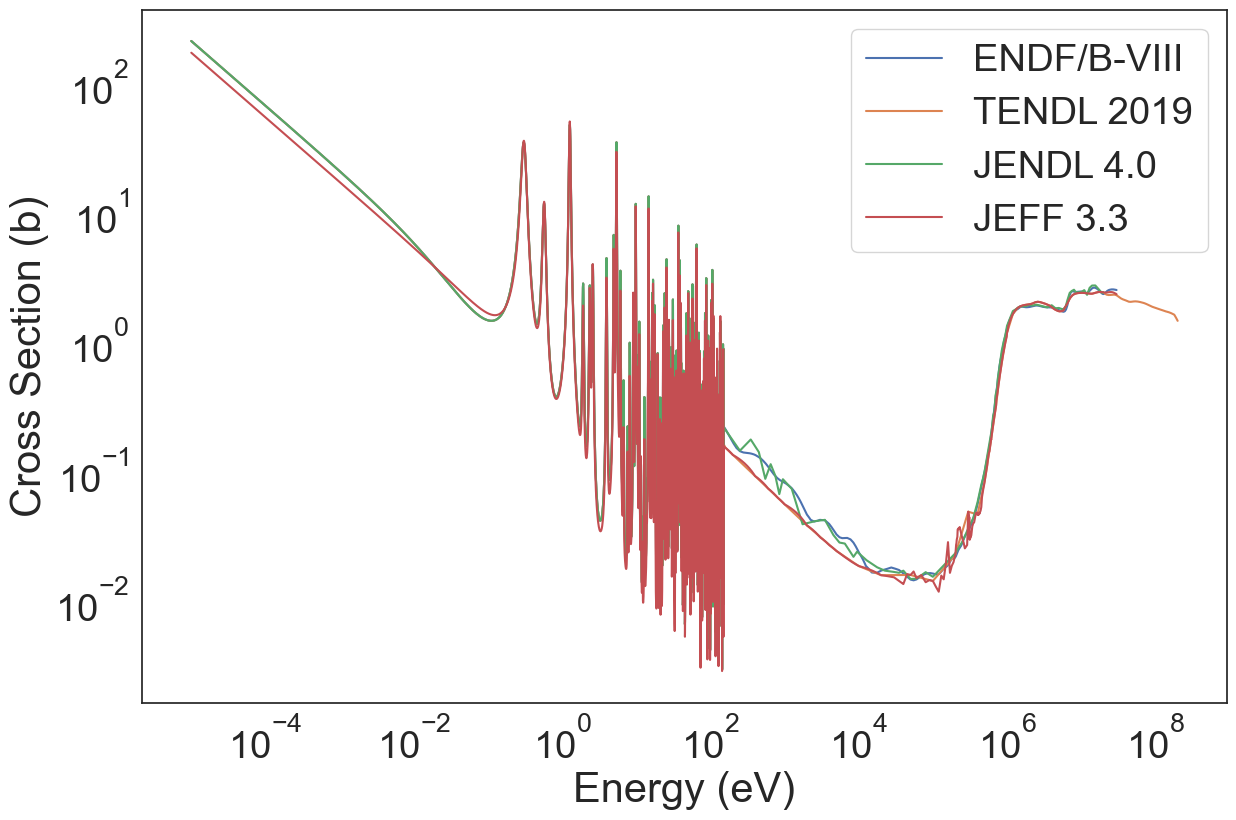

In [97]:
new_evalU235=nuc_data.load_evaluation("Am241", 18, library='endfb8.0',)
print(new_evalU235.head())
#seems units of new evaluation are in log10(eV) and log10(barns) so we will need to convert these back to linear space before plotting
new_evalU235['Energy'] = 10 ** new_evalU235['Energy']
new_evalU235['Data'] = 10 ** new_evalU235['Data']
print(new_evalU235.head())
import nucml.evaluation.plot as eval_plot
eval_plot.plot("Am241", 18, save=True, save_dir=figure_dir)